In [1]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

# Dask will automatically submit SLURM jobs for you
cluster = SLURMCluster(
    cores=8,
    memory="128GB",
    processes=8,
    walltime="08:00:00",
    #qos="np",
    #account='spitfabi',
    #interface='ib0'  # or 'eth0', depends on your HPC
    job_extra_directives=[
        "--account=spitvent",
        "--qos=np"
        # "--constraint=haswell",
        # "--exclusive",
        # "--mail-type=END,FAIL",
        # "--mail-user=your.email@domain.com"
    ]
)

# Scale to desired number of workers
cluster.scale(jobs=1)  # This submits 1 SLURM job
# Connect client
client = Client(cluster)
#cluster.adapt(minimum_jobs=1, maximum_jobs=4)


/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34367 instead
  warnings.warn(


In [2]:
import check_run as cr
from matplotlib import pyplot as plt
import xarray as xr
import os
import importlib as imp
%matplotlib inline

In [6]:
user = 3*['itcv']
exps = [ 'ctl0', 'amix', 'amiy', 'amib', 'amiz', 'amik', 'amiw', 'amij', 'amid', 'cmid']
exps = ['pic7', 'ami7', 'cmi7']
colors = ['lightblue', 'black', 'gray', 'lightgreen', 'black', 'gray', 'violet', 'black', 'gray']
read_again = [] # [ 'exp2', 'exp3', 'exp4', 'exp6', 'res1']#, 'exp3']#, 'exp5']

#colors = ['red', 'blue', 'green', 'maroon', 'violet', 'purple', 'orange', 'lightblue', 'lightgreen', 'magenta']
cart_exp = '/ec/res4/scratch/{}/ece4/'
cart_out = '/ec/res4/hpcperm/itcv/analysis/'


In [4]:
imp.reload(cr)

<module 'check_run' from '/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py'>

pic7
Already computed, reading clim..
ami7
Already computed, reading clim..
cmi7
Computing clim...
Using last 20 years for climatology
Using last 20 years for climatology
Done! Check results in /ec/res4/hpcperm/itcv/analysis//check_pic7-ami7-cmi7/


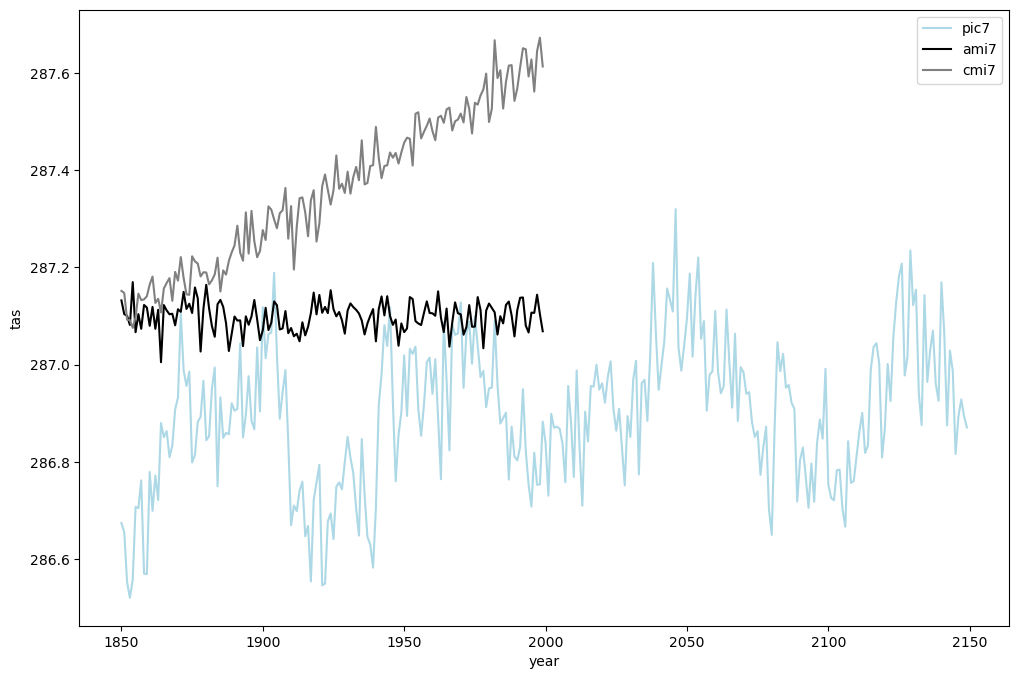

In [9]:
clim_all, allfigs = cr.compare_multi_exps(exps, user, read_again = [], cart_exp=cart_exp, cart_out=cart_out, atm_only=True, imbalance=-0.75, ref_exp='ctl0',  density = True, colors=colors)

cmi7
Already computed, reading clim..
ami7
Already computed, reading clim..


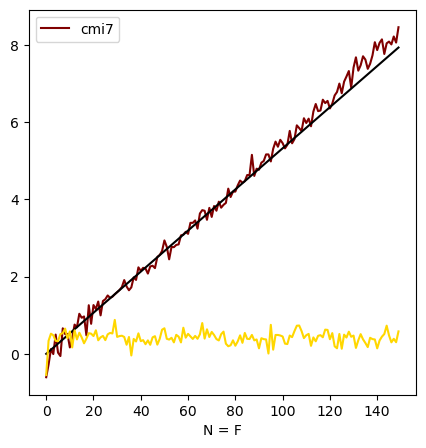

In [10]:
exps = [['cmi7', 'ami7']] #, ['cmi1', 'ami1']]
fig, ax = plt.subplots(1,1, figsize=(5,5))

colors = ['maroon', 'orange']
imp.reload(cr)

for i, exp in enumerate(exps):
    N, F, N0 = cr.compute_rad_components(exp, 2*['itcv'],cart_exp=cart_exp, cart_out=cart_out)
    ax.plot(N, color=colors[i], label=exp[0])
    ax.plot(F, color='k')
    ax.plot(N0, color='gold')
    
ax.set_xlabel('N = F')
ax.legend()
plt.show()

# Compute map of radiative forcing

In [11]:
exps = ['ami7', 'cmi7']
path = '/ec/res4/scratch/itcv/ece4/'

time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
ctl = xr.open_mfdataset(path+exps[0]+'/output/oifs_remap/*_atm_cmip6_1m_*.nc', decode_times=time_coder)
pct = xr.open_mfdataset(path+exps[1]+'/output/oifs_remap/*_atm_cmip6_1m_*.nc', decode_times=time_coder)

In [12]:
ctl = ctl.groupby('time_counter.year').mean()
pct = pct.groupby('time_counter.year').mean()

In [13]:
ctl_toa = ctl.rsdt - ctl.rlut - ctl.rsut
pct_toa = pct.rsdt - pct.rlut - pct.rsut

In [14]:
clim = ctl_toa.mean(axis=0)
forcing = pct_toa - clim

In [15]:
toa_cs  = pct.rlntcs + pct.rsntcs
toa_net = pct.rlnt + pct.rsnt
toa_cloud = toa_net - toa_cs

toa_cs_lw = pct.rlntcs
toa_cs_sw = pct.rsntcs
toa_cloud_lw = pct.rlnt - pct.rlntcs
toa_cloud_sw = pct.rsnt - pct.rsntcs

In [16]:
forcing_cs = toa_cs - (ctl.rlntcs + ctl.rsntcs).mean(axis=0)
forcing_net = toa_net - (ctl.rlnt + ctl.rsnt).mean(axis=0)
forcing_cloud = forcing_net - forcing_cs
forcing_cs_lw = toa_cs_lw - ctl.rlntcs.mean(axis=0)
forcing_cs_sw = toa_cs_sw - ctl.rsntcs.mean(axis=0)
forcing_cloud_lw = toa_cloud_lw - (ctl.rlnt - ctl.rlntcs).mean(axis=0)
forcing_cloud_sw = toa_cloud_sw - (ctl.rsnt - ctl.rsntcs).mean(axis=0) 

In [17]:
forcing_ds = xr.Dataset(
    data_vars=dict(
        forcing=(["year", "lat", "lon"], forcing.data, {"long_name": "forcing"}),  
        forcing_cs=(["year", "lat", "lon"], forcing_cs.data, {"long_name": "clear-sky forcing"}),
        forcing_net=(["year", "lat", "lon"], forcing_net.data, {"long_name": "net forcing"}),
        forcing_cloud=(["year", "lat", "lon"], forcing_cloud.data, {"long_name": "cloud forcing"}),
        forcing_cs_lw=(["year", "lat", "lon"], forcing_cs_lw.data, {"long_name": "clear-sky longwave forcing"}),
        forcing_cs_sw=(["year", "lat", "lon"], forcing_cs_sw.data, {"long_name": "clear-sky shortwave forcing"}),
        forcing_cloud_lw=(["year", "lat", "lon"], forcing_cloud_lw.data, {"long_name": "cloud longwave forcing"}),
        forcing_cloud_sw=(["year", "lat", "lon"], forcing_cloud_sw.data, {"long_name": "cloud shortwave forcing"}),),
    coords=dict(
        lon=("lon", pct_toa.lon.data),
        lat=("lat", pct_toa.lat.data),
        year = ('year', pct_toa.year.data)
    ),)

In [18]:
forcing_ds.to_netcdf('/ec/res4/hpcperm/itcv/analysis/forcing_1pct/'+'pct7_forcing.nc')

/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.39 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [19]:
forcing_ds.forcing

<xarray.DataArray 'forcing' (year: 150, lat: 90, lon: 180)> Size: 10MB
dask.array<sub, shape=(150, 90, 180), dtype=float32, chunksize=(1, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat      (lat) float64 720B -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 1996 1997 1998 1999
Attributes:
    long_name:  forcing